# 06 - EDA Encuestas Y Percepcion

## Hipotesis iniciales

1. Peor NPS, puntuacion o sentimiento por zona deberia asociarse con mayor churn posterior.
2. Las incoherencias entre texto y puntuacion pueden senalar problemas de medicion o clientes con percepcion ambigua.
3. El texto libre puede aportar pistas cualitativas sobre causas de abandono, aunque su volumen puede no justificar NLP avanzado en esta version.
4. Al haber menos encuestas que registros cliente-mes, las senales deben agregarse por zona-mes para evitar sparsity excesiva.
5. Las encuestas pueden capturar clima de satisfaccion de la zona, complementando calidad de red y soporte.

## Que se va a contrastar

- Evolucion temporal de NPS, puntuacion, sentimiento y stress.
- Relacion entre metricas agregadas de encuesta y churn futuro por zona-mes.
- Palabras frecuentes en texto libre como apoyo cualitativo.


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.float_format = '{:,.3f}'.format

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELING = PROJECT_ROOT / 'data' / 'modeling'
REPORTS = PROJECT_ROOT / 'reports'

from collections import Counter
import re

enc = pd.read_csv(PROCESSED / 'encuestas_texto_clean.csv', parse_dates=['fecha'])
clientes = pd.read_csv(PROCESSED / 'clientes_clean.csv')
churn = pd.read_csv(PROCESSED / 'churn_target_clean.csv', parse_dates=['fecha'])
churn = churn.sort_values(['cliente_id', 'fecha'])
churn['churn_t_plus_1'] = churn.groupby('cliente_id')['churn'].shift(-1)
base = churn.dropna(subset=['churn_t_plus_1'])[['cliente_id','fecha','churn_t_plus_1']].merge(clientes[['cliente_id','zona_id']], on='cliente_id', how='left')
zone_churn = base.groupby(['zona_id','fecha'], as_index=False).agg(churn_t1_rate=('churn_t_plus_1','mean'), clientes=('cliente_id','count'))
zone_enc = enc.groupby(['zona_id','fecha'], as_index=False).agg(
    encuestas=('encuesta_id','count'),
    puntuacion_media=('puntuacion_general_1a5','mean'),
    nps_medio=('nps_0a10','mean'),
    sentimiento_medio=('sent_text_latente','mean'),
    stress_medio=('stress_calidad','mean'),
    incongruentes_rate=('flag_incongruente','mean')
)
df = zone_enc.merge(zone_churn, on=['zona_id','fecha'], how='left')


In [3]:
display(enc.head())
display(df.head())


,encuesta_id,fecha,zona_id,region,tipo_zona,puntuacion_general_1a5,nps_0a10,texto_libre,indice_calidad_global,incidencia_masiva,stress_calidad,flag_incongruente,sent_text_latente,texto_libre_was_missing
0,E77700132,2023-01-01,Z04,Centro,suburbana,3,0,Desde hace meses no tengo cobertura dentro de ...,35.130,0,0.498,0,-0.913,0
1,E77700023,2023-01-01,Z05,Este,urbana_premium,5,1,En las últimas semanas se corta en llamadas. e...,40.980,0,0.415,1,-0.619,0
2,E77700582,2023-01-01,Z05,Este,urbana_premium,5,0,En mi experiencia la cobertura es mala. la vel...,40.980,0,0.415,1,-0.574,0
3,E77700150,2023-01-01,Z09,Norte,urbana_premium,2,3,En mi experiencia se queda sin servicio. hay m...,41.350,0,0.409,0,-1.000,0
4,E77700247,2023-01-01,Z09,Norte,urbana_premium,3,3,En mi experiencia hay cortes constantes. los d...,41.350,0,0.409,0,-0.700,0


,zona_id,fecha,encuestas,puntuacion_media,nps_medio,sentimiento_medio,stress_medio,incongruentes_rate,churn_t1_rate,clientes
0,Z01,2023-02-01,1,2.000,0.000,-1.000,0.720,0.000,0.023,128.000
1,Z01,2023-03-01,1,3.000,3.000,-0.893,0.757,0.000,0.008,125.000
2,Z01,2023-04-01,1,2.000,4.000,-0.344,0.703,0.000,0.024,124.000
3,Z01,2023-07-01,1,2.000,3.000,0.078,0.728,1.000,0.033,120.000
4,Z01,2023-08-01,2,3.000,0.000,-0.762,0.713,0.000,0.026,116.000


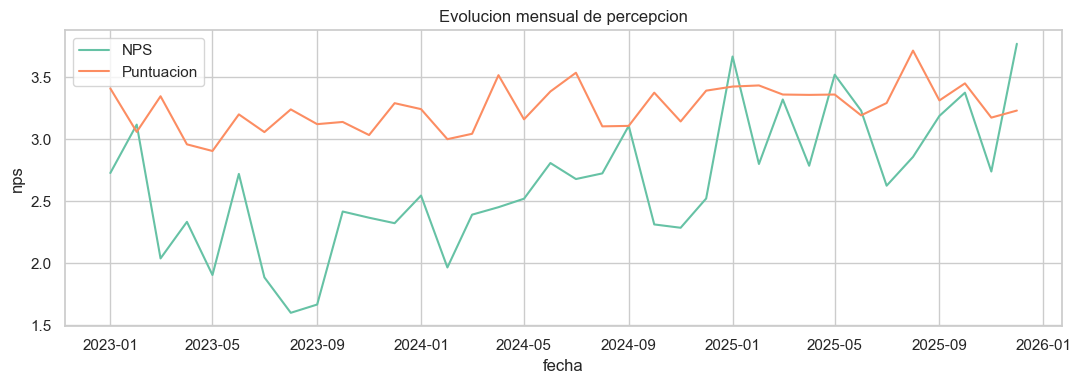

In [4]:
monthly = enc.groupby('fecha', as_index=False).agg(nps=('nps_0a10','mean'), puntuacion=('puntuacion_general_1a5','mean'), sentimiento=('sent_text_latente','mean'))
plt.figure(figsize=(11, 4))
sns.lineplot(data=monthly, x='fecha', y='nps', label='NPS')
sns.lineplot(data=monthly, x='fecha', y='puntuacion', label='Puntuacion')
plt.title('Evolucion mensual de percepcion')
plt.tight_layout()
plt.show()


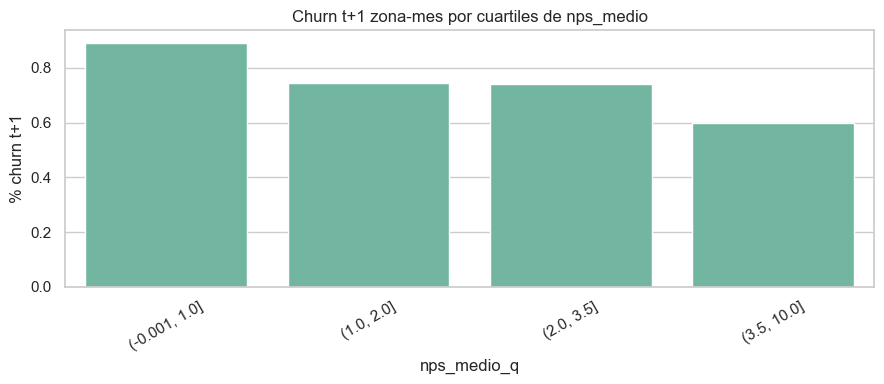

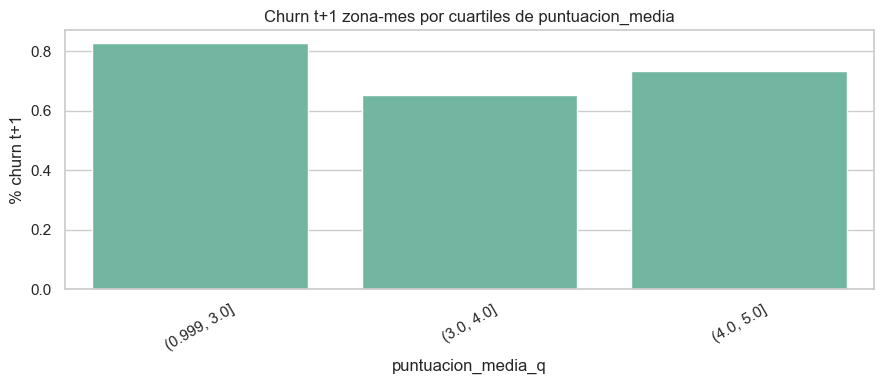

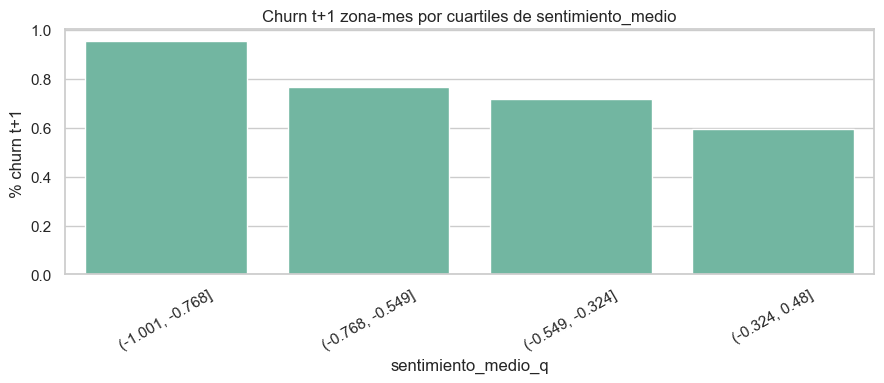

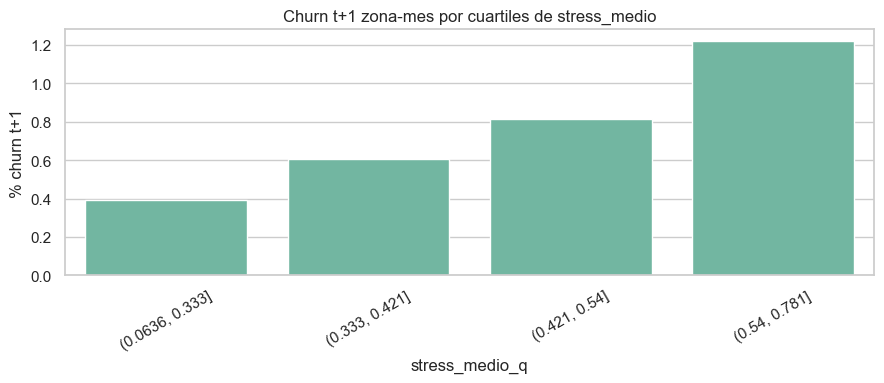

In [5]:
for col in ['nps_medio', 'puntuacion_media', 'sentimiento_medio', 'stress_medio']:
    plot_df = df.dropna(subset=[col, 'churn_t1_rate']).copy()
    plot_df[f'{col}_q'] = pd.qcut(plot_df[col], q=4, duplicates='drop')
    rates = plot_df.groupby(f'{col}_q').agg(churn_rate=('churn_t1_rate','mean'), zonas_mes=('zona_id','count')).reset_index()
    rates['churn_rate'] *= 100
    plt.figure(figsize=(9, 4))
    sns.barplot(data=rates, x=f'{col}_q', y='churn_rate')
    plt.title(f'Churn t+1 zona-mes por cuartiles de {col}')
    plt.ylabel('% churn t+1')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


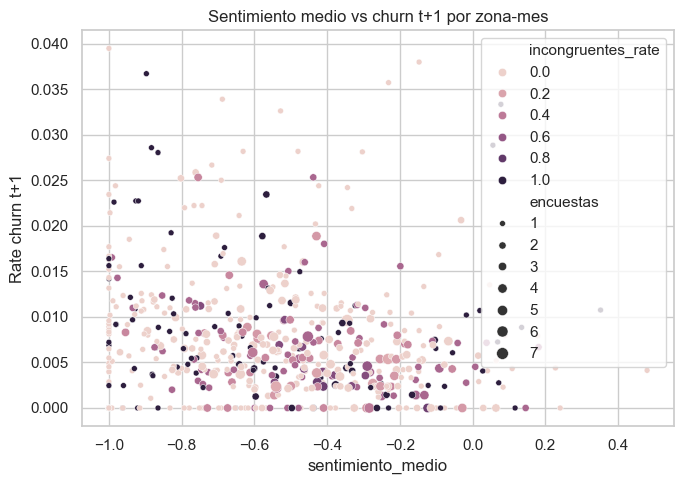

In [6]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='sentimiento_medio', y='churn_t1_rate', size='encuestas', hue='incongruentes_rate')
plt.title('Sentimiento medio vs churn t+1 por zona-mes')
plt.ylabel('Rate churn t+1')
plt.tight_layout()
plt.show()


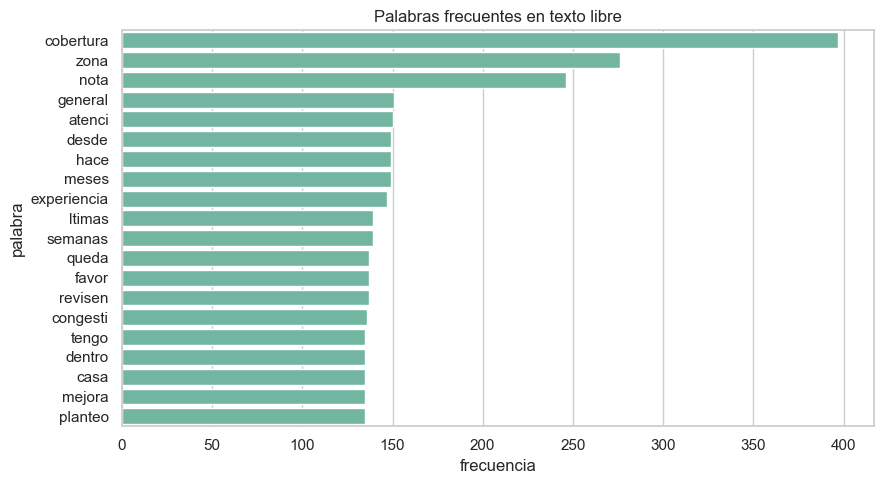

In [7]:
text = ' '.join(enc['texto_libre'].dropna().astype(str).str.lower())
words = re.findall(r'[a-z???????]{4,}', text)
stop = {'para','pero','como','este','esta','todo','toda','servicio','cliente','clientes','comentario'}
counts = Counter(w for w in words if w not in stop)
word_df = pd.DataFrame(counts.most_common(20), columns=['palabra', 'frecuencia'])
plt.figure(figsize=(9, 5))
sns.barplot(data=word_df, y='palabra', x='frecuencia')
plt.title('Palabras frecuentes en texto libre')
plt.tight_layout()
plt.show()


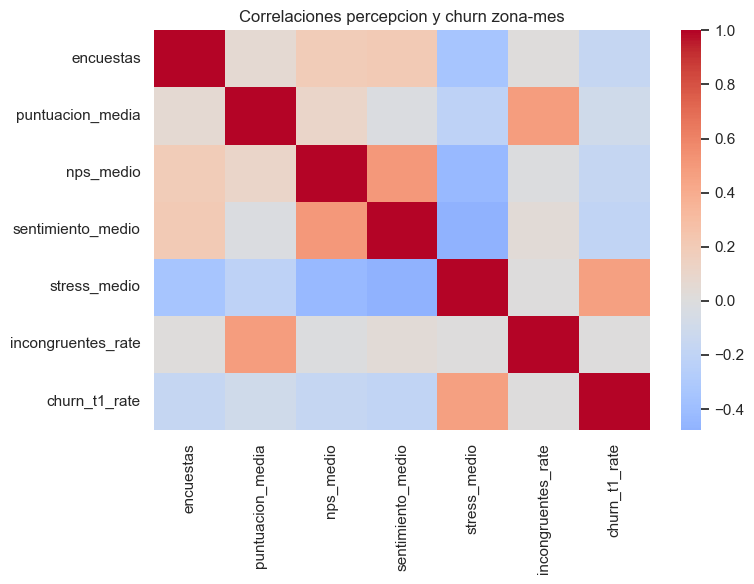

churn_t1_rate         1.000
stress_medio          0.461
incongruentes_rate    0.004
puntuacion_media     -0.091
encuestas            -0.162
nps_medio            -0.164
sentimiento_medio    -0.186
Name: churn_t1_rate, dtype: float64

In [8]:
corr_cols = ['encuestas', 'puntuacion_media', 'nps_medio', 'sentimiento_medio', 'stress_medio', 'incongruentes_rate', 'churn_t1_rate']
corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlaciones percepcion y churn zona-mes')
plt.tight_layout()
plt.show()
display(corr['churn_t1_rate'].sort_values(ascending=False))


## Conclusiones finales

- Las encuestas aportan senales contextuales de percepcion, pero su menor volumen obliga a agregarlas por `zona_id` y `fecha`.
- El stress medio aparece como la asociacion mas fuerte con churn futuro en este EDA, con correlacion positiva cercana a 0.461.
- NPS, puntuacion y sentimiento muestran relacion negativa con churn, coherente con la hipotesis de que peor percepcion aumenta riesgo.
- Las incongruencias entre texto y puntuacion pueden conservarse como senal auxiliar, aunque no parecen ser el principal driver por si solas.
- El texto libre es mas util para explicar temas recurrentes y dar contexto de negocio que para entrenar un modelo NLP complejo en esta iteracion.

## Decisiones para feature engineering

- Agregar encuestas por `zona_id` y `fecha`.
- Incluir NPS medio, puntuacion media, sentimiento medio, stress e incongruencias.
- Crear indicadores de disponibilidad de encuesta para distinguir ausencia de senal de mala percepcion.
- No aplicar NLP avanzado en esta iteracion.
- Usar palabras frecuentes solo como apoyo interpretativo en documentacion y conclusiones.
